In [1]:
# This cell imports the libraries we need for working with NinaPro data.
# Think of libraries like "tools" we add to Python to do specific tasks.

# scipy.io: For loading .mat files (MATLAB format)
import scipy.io as sio

# numpy: For numerical operations (like arrays and math)
import numpy as np

# matplotlib.pyplot: For plotting graphs (to visualize EMG signals)
import matplotlib.pyplot as plt

In [2]:
# This cell loads the S1_A1_E1.mat file from your ninaprodb folder.

# Path to the file (adjust if your folder is named differently)
file_path = '../ninaprodb/s1/S1_A1_E1.mat'

# Load the .mat file into a variable called 'data'
data = sio.loadmat(file_path)

# Print all the "keys" (names of the data inside the file)
print("Keys in the .mat file:", data.keys())

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])


In [3]:
# Extract data with correct assumptions
emg = data['emg']  # Shape: (101014, 10) = (samples, electrodes)
restimulus = data['restimulus'].flatten()  # Shape: (101014,)
fs = 100  # Preprocessed to 100 Hz (from the paper)

print("EMG shape:", emg.shape)  # (101014, 10)
print("Restimulus shape:", restimulus.shape)
print("Sampling frequency:", fs, "Hz")
print("Unique gestures:", np.unique(restimulus))  # Should show 1-12

EMG shape: (101014, 10)
Restimulus shape: (101014,)
Sampling frequency: 100 Hz
Unique gestures: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


In [4]:
# Plot EMG for gesture 1 (Index Flexion)
gesture_id = 1
gesture_indices = np.where(restimulus == gesture_id)[0]

# Take first 200 samples (2 seconds at 100 Hz)
start_idx = gesture_indices[0]
end_idx = start_idx + 200

plt.figure(figsize=(12, 6))
for i in range(10):  # 10 electrodes
    plt.plot(emg[start_idx:end_idx, i], label=f'Electrode {i+1}')
plt.xlabel('Samples (at 100 Hz)')
plt.ylabel('EMG Amplitude')
plt.title(f'Preprocessed EMG for Gesture {gesture_id} (Index Flexion)')
plt.legend()
plt.grid()
plt.show()

<Figure size 1200x600 with 1 Axes>

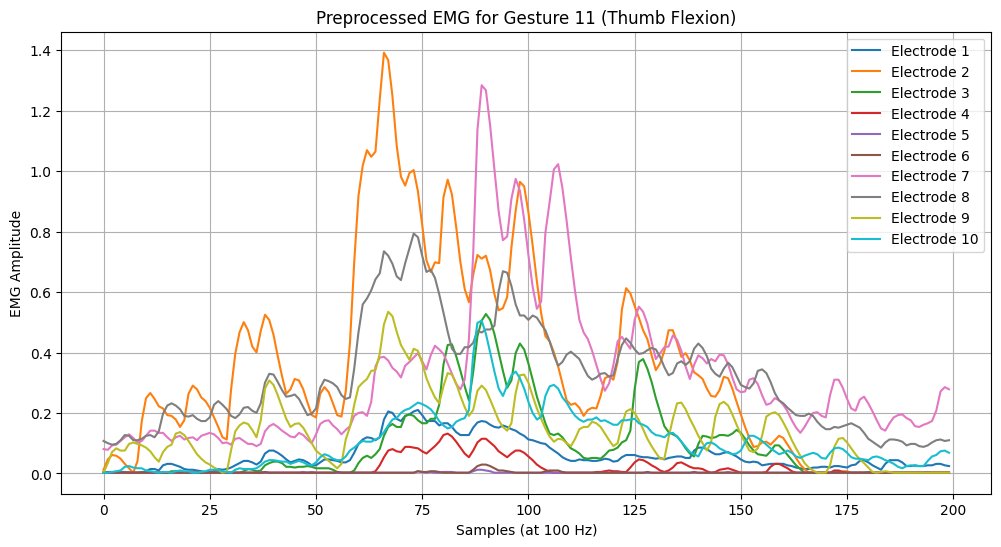

In [5]:
# Plot EMG for gesture 11 (Thumb Flexion)
gesture_id = 11
gesture_indices = np.where(restimulus == gesture_id)[0]

start_idx = gesture_indices[0]
end_idx = start_idx + 200

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(emg[start_idx:end_idx, i], label=f'Electrode {i+1}')
plt.xlabel('Samples (at 100 Hz)')
plt.ylabel('EMG Amplitude')
plt.title(f'Preprocessed EMG for Gesture {gesture_id} (Thumb Flexion)')
plt.legend()
plt.grid()
plt.show()

In [6]:
# Print shapes of important arrays
print("emg shape:", data['emg'].shape)
print("stimulus shape:", data['stimulus'].shape)
print("subject:", data['subject'])
print("exercise:", data['exercise'])
print("repetition shape:", data['repetition'].shape)
print("restimulus shape:", data['restimulus'].shape)

emg shape: (101014, 10)
stimulus shape: (101014, 1)
subject: [[1]]
exercise: [[1]]
repetition shape: (101014, 1)
restimulus shape: (101014, 1)


In [7]:
import numpy as np

# Flatten the arrays (they are (n,1) shape)
stimulus = data['stimulus'].flatten()
restimulus = data['restimulus'].flatten()
repetition = data['repetition'].flatten()

# Print unique values
print("Unique gestures (stimulus):", np.unique(stimulus))
print("Unique repetitions:", np.unique(repetition))
print("Number of gesture starts (restimulus):", len(restimulus))
print("First 10 restimulus indices:", restimulus[:10])

Unique gestures (stimulus): [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Unique repetitions: [ 0  1  2  3  4  5  6  7  8  9 10]
Number of gesture starts (restimulus): 101014
First 10 restimulus indices: [0 0 0 0 0 0 0 0 0 0]


In [8]:
import numpy as np

# Flatten restimulus
restimulus = data['restimulus'].flatten()

# Find where restimulus changes (gesture starts)
# We compare each sample to the previous one
gesture_starts = np.where(np.diff(restimulus) != 0)[0] + 1  # +1 because diff shifts left

# Also include the very first sample (index 0)
gesture_starts = np.insert(gesture_starts, 0, 0)

print("Number of gesture starts:", len(gesture_starts))
print("First 20 start indices:", gesture_starts[:20])
print("Restimulus at start indices:", restimulus[gesture_starts[:20]])

Number of gesture starts: 241
First 20 start indices: [   0  440  745 1275 1629 2153 2499 3020 3391 3743 4181 4619 4991 5435
 5865 6339 6751 7075 7510 7964]
Restimulus at start indices: [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


In [9]:
# Get restimulus at all start indices
gestures_at_starts = restimulus[gesture_starts]

print("All gestures at start indices:", np.unique(gestures_at_starts))
print("Count per gesture:")
for g in np.unique(gestures_at_starts):
    print(f"  Gesture {g}: {np.sum(gestures_at_starts == g)} times")

All gestures at start indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Count per gesture:
  Gesture 0: 121 times
  Gesture 1: 10 times
  Gesture 2: 10 times
  Gesture 3: 10 times
  Gesture 4: 10 times
  Gesture 5: 10 times
  Gesture 6: 10 times
  Gesture 7: 10 times
  Gesture 8: 10 times
  Gesture 9: 10 times
  Gesture 10: 10 times
  Gesture 11: 10 times
  Gesture 12: 10 times


In [10]:
# Assume sampling rate is 2000 Hz (common in NinaDB)
fs = 2000  # samples per second

# Let's check the time between consecutive gesture starts
time_between_starts = np.diff(gesture_starts) / fs  # in seconds

print("Time between first 20 gesture starts (seconds):")
print(time_between_starts[:20])
print("\nAverage time between starts:", np.mean(time_between_starts), "seconds")
print("Min time:", np.min(time_between_starts), "seconds")
print("Max time:", np.max(time_between_starts), "seconds")

Time between first 20 gesture starts (seconds):
[0.22   0.1525 0.265  0.177  0.262  0.173  0.2605 0.1855 0.176  0.219
 0.219  0.186  0.222  0.215  0.237  0.206  0.162  0.2175 0.227  0.176 ]

Average time between starts: 0.20970000000000003 seconds
Min time: 0.092 seconds
Max time: 0.441 seconds


In [11]:
fs = 100  # samples per second (as per NinaDB preprocessing)

# Recalculate time between starts
time_between_starts = np.diff(gesture_starts) / fs  # in seconds

print("Time between first 20 gesture starts (seconds) with fs=100Hz:")
print(time_between_starts[:20])
print("\nAverage time between starts:", np.mean(time_between_starts), "seconds")
print("Min time:", np.min(time_between_starts), "seconds")
print("Max time:", np.max(time_between_starts), "seconds")

Time between first 20 gesture starts (seconds) with fs=100Hz:
[4.4  3.05 5.3  3.54 5.24 3.46 5.21 3.71 3.52 4.38 4.38 3.72 4.44 4.3
 4.74 4.12 3.24 4.35 4.54 3.52]

Average time between starts: 4.194 seconds
Min time: 1.84 seconds
Max time: 8.82 seconds


In [12]:
print("Exercise value:", data['exercise'])
print("Subject value:", data['subject'])
print("Are there multiple exercises in this file?", "exercise" in data and len(data['exercise']) > 1)

Exercise value: [[1]]
Subject value: [[1]]
Are there multiple exercises in this file? False


In [13]:
# For each gesture start, how many samples until the next start?
samples_per_gesture = np.diff(gesture_starts)
print("Samples per segment (first 20):", samples_per_gesture[:20])
print("Average samples per segment:", np.mean(samples_per_gesture))

Samples per segment (first 20): [440 305 530 354 524 346 521 371 352 438 438 372 444 430 474 412 324 435
 454 352]
Average samples per segment: 419.4


In [14]:
# Get all start indices where restimulus is 1 (Gesture 1)
gesture_1_starts = gesture_starts[restimulus[gesture_starts] == 1]

# For each start, get the next start (end of this gesture)
# The next start is the next index in gesture_starts
# But we need to pair each start with the next one
gesture_1_ends = []
for i, start in enumerate(gesture_1_starts):
    # Find the next start index in gesture_starts that is > start
    next_idx = np.searchsorted(gesture_starts, start, side='right')
    if next_idx < len(gesture_starts):
        end = gesture_starts[next_idx]
        gesture_1_ends.append(end)
    else:
        # If no next start, use the end of the data
        gesture_1_ends.append(len(restimulus))

gesture_1_ends = np.array(gesture_1_ends)

# Now, for each Gesture 1, get the EMG window
emg = data['emg']  # (101014, 10)
gesture_1_windows = []
for start, end in zip(gesture_1_starts, gesture_1_ends):
    window = emg[start:end, :]  # (n_samples, 10)
    gesture_1_windows.append(window)
    print(f"Gesture 1 rep: start={start}, end={end}, duration={end-start} samples")

print(f"\nTotal Gesture 1 repetitions: {len(gesture_1_windows)}")
print(f"Average duration: {np.mean(gesture_1_ends - gesture_1_starts)} samples")

Gesture 1 rep: start=440, end=745, duration=305 samples
Gesture 1 rep: start=1275, end=1629, duration=354 samples
Gesture 1 rep: start=2153, end=2499, duration=346 samples
Gesture 1 rep: start=3020, end=3391, duration=371 samples
Gesture 1 rep: start=3743, end=4181, duration=438 samples
Gesture 1 rep: start=4619, end=4991, duration=372 samples
Gesture 1 rep: start=5435, end=5865, duration=430 samples
Gesture 1 rep: start=6339, end=6751, duration=412 samples
Gesture 1 rep: start=7075, end=7510, duration=435 samples
Gesture 1 rep: start=7964, end=8316, duration=352 samples

Total Gesture 1 repetitions: 10
Average duration: 381.5 samples


In [15]:
# For each gesture (1-12), get all start indices and durations
for g in range(1, 13):
    starts = gesture_starts[restimulus[gesture_starts] == g]
    ends = []
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        ends.append(end)
    ends = np.array(ends)
    durations = ends - starts
    print(f"Gesture {g}: {len(starts)} reps, durations (samples): {durations}, avg={np.mean(durations):.1f}")
    

Gesture 1: 10 reps, durations (samples): [305 354 346 371 438 372 430 412 435 352], avg=381.5
Gesture 2: 10 reps, durations (samples): [193 388 233 234 244 252 316 227 229 302], avg=261.8
Gesture 3: 10 reps, durations (samples): [524 390 481 433 460 515 199 360 424 356], avg=414.2
Gesture 4: 10 reps, durations (samples): [348 296 287 276 281 242 278 315 330 329], avg=298.2
Gesture 5: 10 reps, durations (samples): [452 453 382 416 376 418 430 339 318 368], avg=395.2
Gesture 6: 10 reps, durations (samples): [293 305 432 286 301 306 254 299 253 329], avg=305.8
Gesture 7: 10 reps, durations (samples): [246 240 266 263 252 187 259 325 299 278], avg=261.5
Gesture 8: 10 reps, durations (samples): [211 294 277 359 333 372 374 287 306 185], avg=299.8
Gesture 9: 10 reps, durations (samples): [197 250 234 222 295 281 269 330 289 241], avg=260.8
Gesture 10: 10 reps, durations (samples): [458 184 184 270 407 188 338 379 473 306], avg=318.7
Gesture 11: 10 reps, durations (samples): [186 285 305 195 

In [16]:
# Initialize lists to store features and labels
X = []  # will be (n_repetitions, 10)
y = []  # gesture labels (1-12)

# Loop over gestures 1-12
for g in range(1, 13):
    # Get all start indices for this gesture
    starts = gesture_starts[restimulus[gesture_starts] == g]
    for start in starts:
        # Find the end index (next gesture start)
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)

        # Extract EMG window: (duration, 10)
        window = emg[start:end, :]

        # Compute mean per electrode (across time)
        mean_emg = np.mean(window, axis=0)  # (10,) array

        X.append(mean_emg)
        y.append(g)

# Convert to numpy arrays
X = np.array(X)  # (120, 10)  (12 gestures × 10 reps)
y = np.array(y)   # (120,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 labels:", y[:5])

X shape: (120, 10)
y shape: (120,)
First 5 labels: [1 1 1 1 1]


              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       0.50      1.00      0.67         2
           5       1.00      1.00      1.00         2
           6       0.50      0.50      0.50         2
           7       1.00      0.50      0.67         2
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2

    accuracy                           0.83        24
   macro avg       0.89      0.83      0.83        24
weighted avg       0.89      0.83      0.83        24



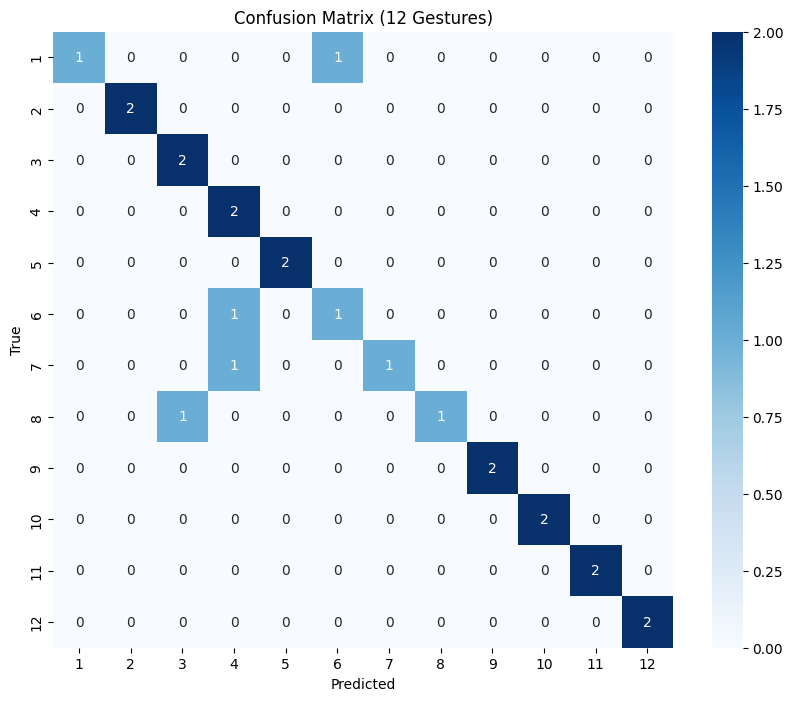

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title("Confusion Matrix (12 Gestures)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [18]:
# Rebuild X with more features
X_enhanced = []
for g in range(1, 13):
    starts = gesture_starts[restimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        window = emg[start:end, :]  # (duration, 10)

        # Compute features per electrode
        features = []
        for electrode in range(10):
            signal = window[:, electrode]
            features.extend([
                np.mean(signal),    # Mean
                np.std(signal),     # Standard deviation
                np.min(signal),     # Min
                np.max(signal),     # Max
                np.sqrt(np.mean(signal**2))  # RMS
            ])
        X_enhanced.append(features)

X_enhanced = np.array(X_enhanced)  # (120, 50)  (10 electrodes × 5 features)
y = np.array(y)  # Same as before

print("New X shape:", X_enhanced.shape)

New X shape: (120, 50)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.50      0.50      0.50         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      1.00      1.00         2

    accuracy                           0.88        24
   macro avg       0.90      0.88      0.87        24
weighted avg       0.90      0.88      0.87        24



In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(classification_report(y_test, y_pred_knn, zero_division=0))

              precision    recall  f1-score   support

           1       0.50      0.50      0.50         2
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.67      1.00      0.80         2
           7       1.00      0.50      0.67         2
           8       1.00      0.50      0.67         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      0.50      0.67         2

    accuracy                           0.79        24
   macro avg       0.85      0.79      0.78        24
weighted avg       0.85      0.79      0.78        24



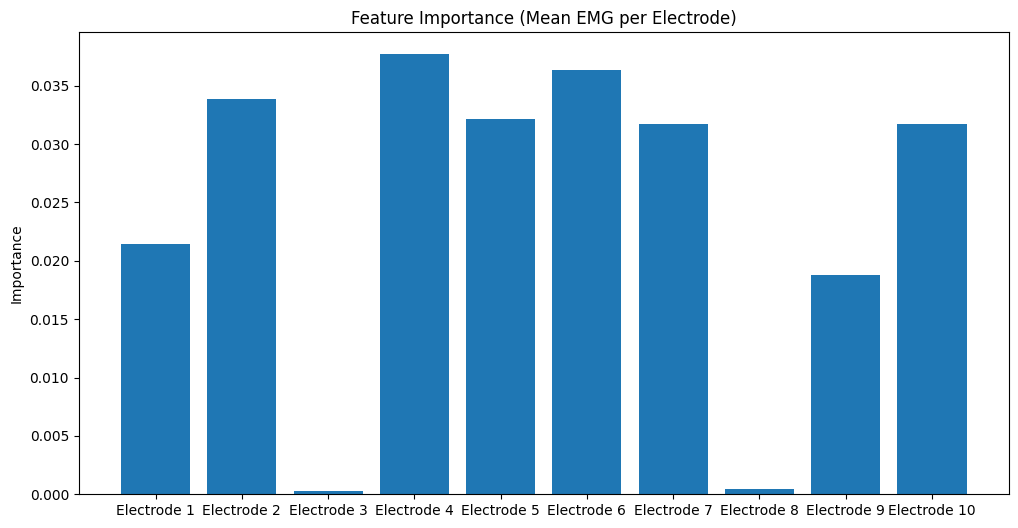

In [21]:
# Get feature importances from Random Forest
importances = clf.feature_importances_
plt.figure(figsize=(12, 6))
plt.bar(range(10), importances[:10])  # First 10 features (mean per electrode)
plt.xticks(range(10), [f"Electrode {i+1}" for i in range(10)])
plt.title("Feature Importance (Mean EMG per Electrode)")
plt.ylabel("Importance")
plt.show()

Trimming all windows to: 193 samples


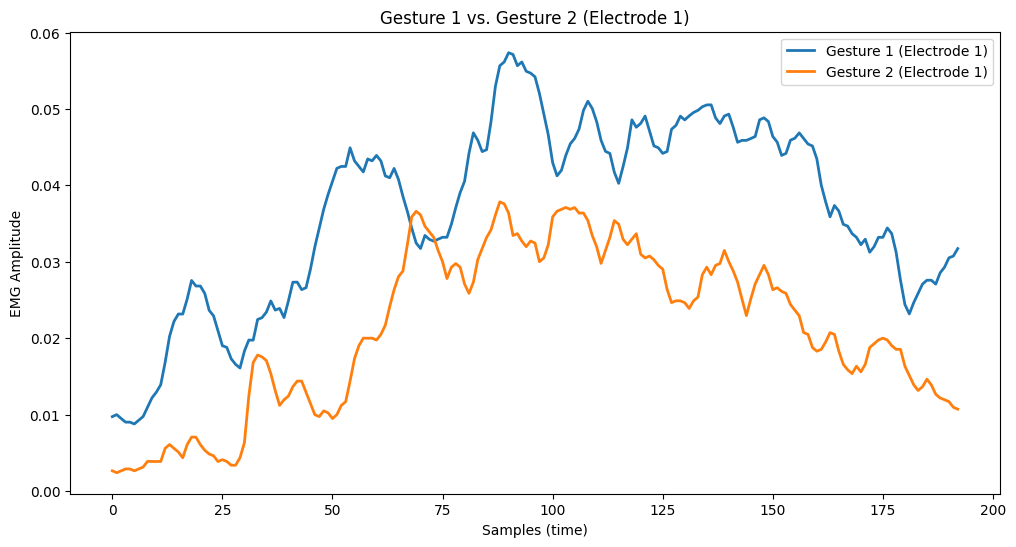

In [22]:
import numpy as np

# Get all Gesture 1 and Gesture 2 windows
gesture_1_windows = []
gesture_2_windows = []

for g in [1, 2]:
    starts = gesture_starts[restimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        window = emg[start:end, :]  # (duration, 10)
        if g == 1:
            gesture_1_windows.append(window)
        else:
            gesture_2_windows.append(window)

# Find the minimum length across all windows
min_length = min([w.shape[0] for w in gesture_1_windows + gesture_2_windows])
print("Trimming all windows to:", min_length, "samples")

# Trim all windows to min_length
gesture_1_windows = [w[:min_length, :] for w in gesture_1_windows]
gesture_2_windows = [w[:min_length, :] for w in gesture_2_windows]

# Now compute mean across repetitions
mean_gesture_1 = np.mean(gesture_1_windows, axis=0)  # (min_length, 10)
mean_gesture_2 = np.mean(gesture_2_windows, axis=0)  # (min_length, 10)

# Plot Electrode 0 for both gestures
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(mean_gesture_1[:, 0], label="Gesture 1 (Electrode 1)", linewidth=2)
plt.plot(mean_gesture_2[:, 0], label="Gesture 2 (Electrode 1)", linewidth=2)
plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude")
plt.title("Gesture 1 vs. Gesture 2 (Electrode 1)")
plt.legend()
plt.show()


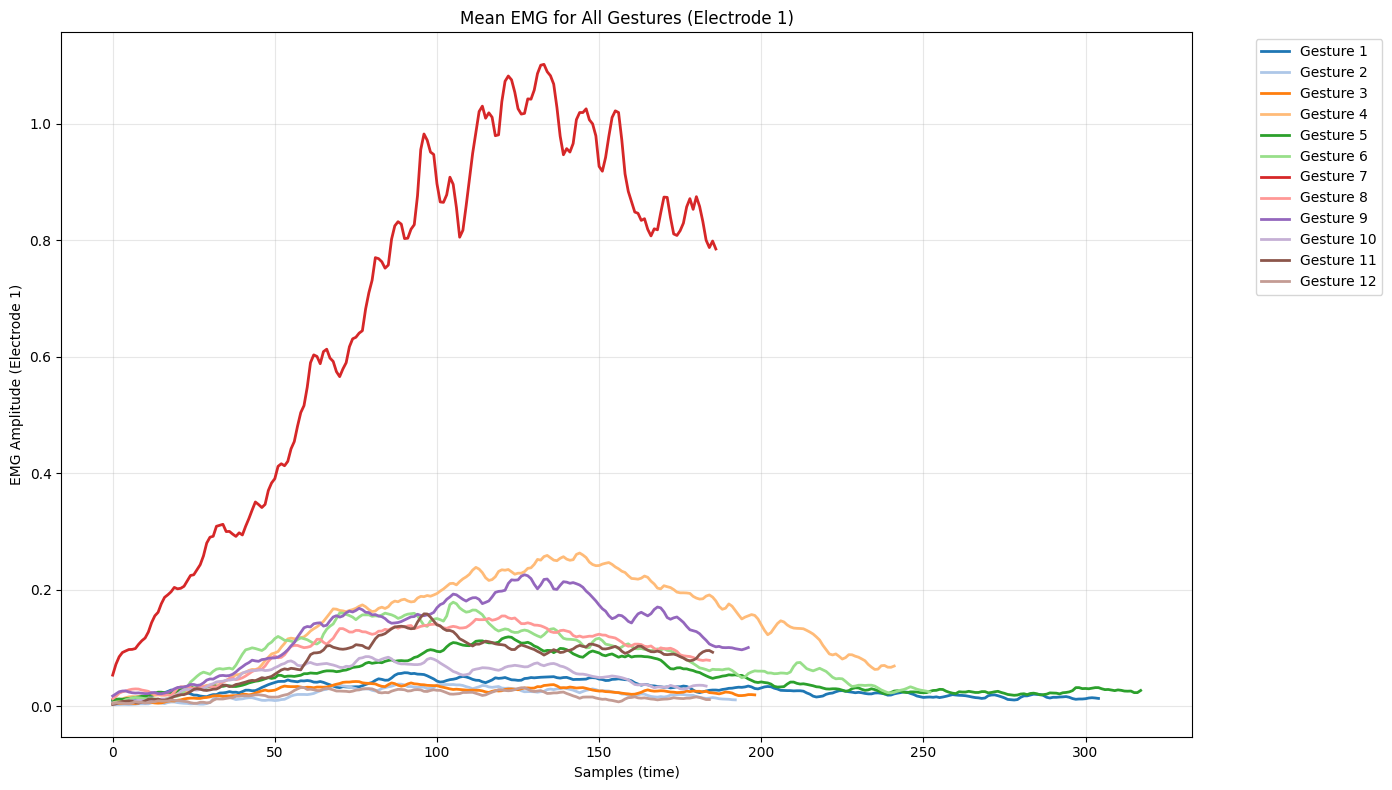

In [23]:
import matplotlib.pyplot as plt

# Define colors for each gesture
colors = plt.cm.tab20.colors  # 20 distinct colors (enough for 12 gestures)

plt.figure(figsize=(14, 8))

# For each gesture (1-12), compute mean window and plot
for g in range(1, 13):
    # Get all windows for this gesture
    windows = []
    starts = gesture_starts[restimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        window = emg[start:end, :]
        windows.append(window)

    # Trim all windows to the same length (min length for this gesture)
    min_len = min([w.shape[0] for w in windows])
    windows = [w[:min_len, :] for w in windows]

    # Compute mean across repetitions for Electrode 0 (first electrode)
    mean_window = np.mean(windows, axis=0)  # (min_len, 10)
    electrode_0 = mean_window[:, 0]  # First electrode

    # Plot
    plt.plot(electrode_0, label=f"Gesture {g}", color=colors[g-1], linewidth=2)

plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude (Electrode 1)")
plt.title("Mean EMG for All Gestures (Electrode 1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside plot
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Rebuild X with 3 sub-windows per gesture
X_subwindows = []
y_subwindows = []

for g in range(1, 13):
    starts = gesture_starts[restimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        window = emg[start:end, :]  # (duration, 10)

        # Split into 3 equal parts
        n = window.shape[0]
        split1 = window[:n//3, :]
        split2 = window[n//3:2*n//3, :]
        split3 = window[2*n//3:, :]

        # Compute mean per electrode for each split
        features = [
            np.mean(split1, axis=0),  # First third (10 features)
            np.mean(split2, axis=0),  # Second third (10 features)
            np.mean(split3, axis=0)   # Third third (10 features)
        ]
        features = np.concatenate(features)  # (30,)
        X_subwindows.append(features)
        y_subwindows.append(g)

X_subwindows = np.array(X_subwindows)  # (120, 30)
y_subwindows = np.array(y_subwindows)

print("New X shape:", X_subwindows.shape)

New X shape: (120, 30)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_subwindows, y_subwindows, test_size=0.2, random_state=42, stratify=y_subwindows
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.50      0.50      0.50         2
           2       1.00      0.50      0.67         2
           3       0.67      1.00      0.80         2
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.67      1.00      0.80         2
           7       1.00      0.50      0.67         2
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2

    accuracy                           0.83        24
   macro avg       0.88      0.83      0.83        24
weighted avg       0.88      0.83      0.83        24



In [26]:
window_size = 20   # 20 samples = 200ms at 100Hz
step_size = 10      # 10 samples = 100ms step -> 50% overlap

X = []      # feature vectors
y = []      # gesture label per window
rep = []    # repetition number per window (needed for a leak-free train/test split later)

for g in range(1, 13):
    # Find all repetition start indices for this gesture, using restimulus
    starts = gesture_starts[restimulus[gesture_starts] == g]

    for start in starts:
        # Find where this repetition ends (next label change)
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)

        rep_number = repetition[start]  # which repetition (1-10) this segment belongs to

        # Slide a window across this repetition
        window_start = start
        while window_start + window_size <= end:
            window = emg[window_start : window_start + window_size, :]  # (window_size, 10)

            # Same feature set you already built: mean, std, min, max, RMS per electrode
            features = []
            for electrode in range(10):
                signal = window[:, electrode]
                features.extend([
                    np.mean(signal),
                    np.std(signal),
                    np.min(signal),
                    np.max(signal),
                    np.sqrt(np.mean(signal**2))
                ])

            X.append(features)
            y.append(g)
            rep.append(rep_number)

            window_start += step_size

X = np.array(X)
y = np.array(y)
rep = np.array(rep)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("rep shape:", rep.shape)
print("Windows per gesture:")
for g in np.unique(y):
    print(f"  Gesture {g}: {np.sum(y == g)} windows")
print("Unique repetition numbers found:", np.unique(rep))

X shape: (3594, 50)
y shape: (3594,)
rep shape: (3594,)
Windows per gesture:
  Gesture 1: 368 windows
  Gesture 2: 247 windows
  Gesture 3: 401 windows
  Gesture 4: 283 windows
  Gesture 5: 380 windows
  Gesture 6: 291 windows
  Gesture 7: 246 windows
  Gesture 8: 285 windows
  Gesture 9: 247 windows
  Gesture 10: 303 windows
  Gesture 11: 235 windows
  Gesture 12: 308 windows
Unique repetition numbers found: [ 1  2  3  4  5  6  7  8  9 10]


Train windows: 2144
Test windows: 1450

=== Random Forest ===
              precision    recall  f1-score   support

           1       0.80      0.85      0.82       152
           2       0.94      0.74      0.83       119
           3       0.66      0.76      0.71       135
           4       0.84      0.85      0.84       112
           5       0.92      0.93      0.92       157
           6       0.61      0.59      0.60       113
           7       0.91      0.89      0.90        97
           8       0.72      0.77      0.75       113
           9       0.69      0.73      0.71       100
          10       0.94      0.87      0.91       117
          11       0.73      0.61      0.67        96
          12       0.83      0.90      0.87       139

    accuracy                           0.80      1450
   macro avg       0.80      0.79      0.79      1450
weighted avg       0.80      0.80      0.80      1450

=== KNN ===
              precision    recall  f1-score   support

    

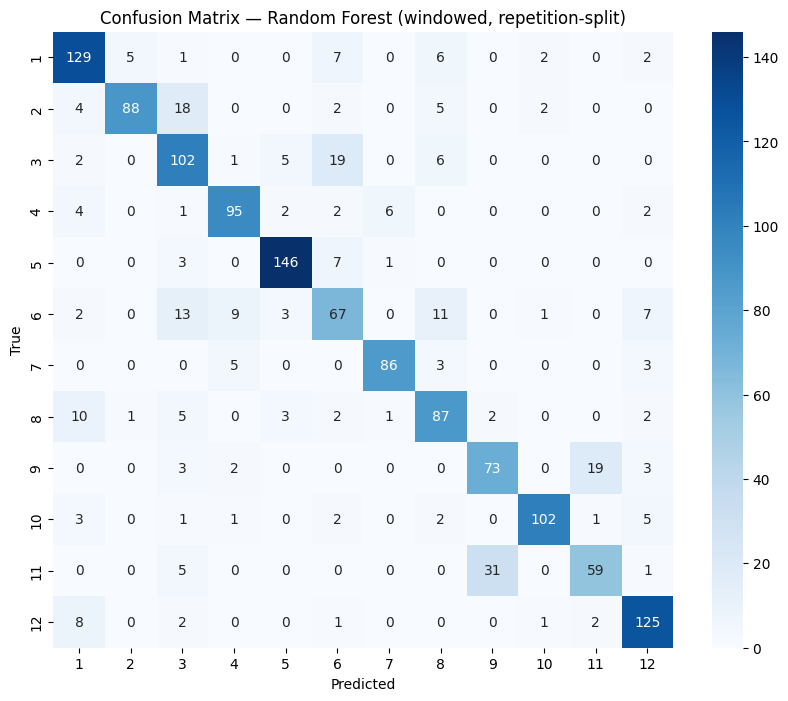

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Split by repetition, not randomly ---
test_reps = [2, 5, 7, 10]
train_mask = ~np.isin(rep, test_reps)
test_mask = np.isin(rep, test_reps)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train windows:", X_train.shape[0])
print("Test windows:", X_test.shape[0])

# --- Scale features (fit on train only) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# --- KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN ===")
print(classification_report(y_test, y_pred_knn, zero_division=0))

# --- Confusion matrix for the better-performing model (adjust if needed) ---
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title("Confusion Matrix — Random Forest (windowed, repetition-split)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

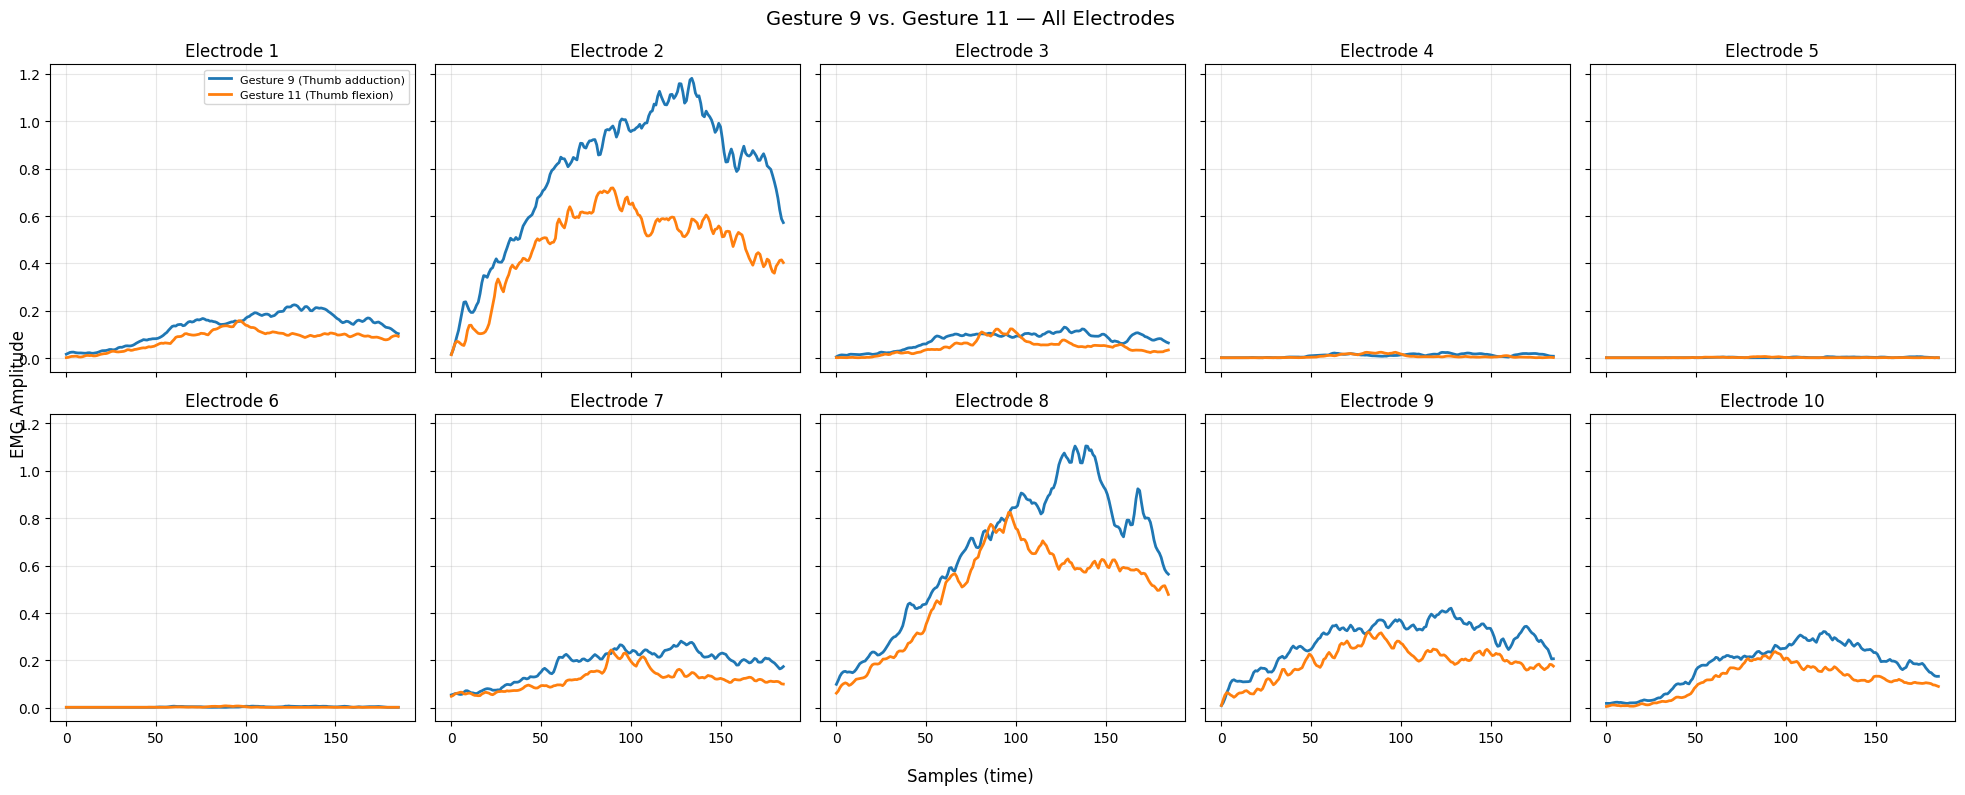

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Get all Gesture 9 and Gesture 11 windows
gesture_1_windows = [ ]
gesture_2_windows = []

for g in [9, 11]:
    starts = gesture_starts[restimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        window = emg[start:end, :]
        if g == 9:
            gesture_1_windows.append(window)
        else:
            gesture_2_windows.append(window)

min_length = min([w.shape[0] for w in gesture_1_windows + gesture_2_windows])
gesture_1_windows = [w[:min_length, :] for w in gesture_1_windows]
gesture_2_windows = [w[:min_length, :] for w in gesture_2_windows]

mean_gesture_1 = np.mean(gesture_1_windows, axis=0)  # (min_length, 10)
mean_gesture_2 = np.mean(gesture_2_windows, axis=0)  # (min_length, 10)

# Grid of subplots: 2 rows x 5 columns = 10 electrodes
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # turns the 2x5 grid into a simple list of 10 axes

for electrode in range(10):
    ax = axes[electrode]
    ax.plot(mean_gesture_1[:, electrode], label="Gesture 9 (Thumb adduction)", linewidth=2)
    ax.plot(mean_gesture_2[:, electrode], label="Gesture 11 (Thumb flexion)", linewidth=2)
    ax.set_title(f"Electrode {electrode + 1}")
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)
fig.supxlabel("Samples (time)")
fig.supylabel("EMG Amplitude")
fig.suptitle("Gesture 9 vs. Gesture 11 — All Electrodes", fontsize=14)
plt.tight_layout()
plt.show()


In [29]:
from tensorflow import keras
from tensorflow.keras import layers

# y is currently 1-12. Keras needs class labels starting at 0 for this loss function.
y_train_nn = y_train - 1
y_test_nn = y_test - 1

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(12, activation='softmax')  # 12 gesture classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-08-04 12:26:09.493796: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,740 (22.42 KB)

 Trainable params: 5,740 (22.42 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from sklearn.utils import shuffle
X_train_scaled, y_train_nn = shuffle(X_train_scaled, y_train_nn, random_state=42)

history = model.fit(
    X_train_scaled, y_train_nn,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7580 - loss: 1.3964 - val_accuracy: 0.7826 - val_loss: 0.6216
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7980 - loss: 0.5851 - val_accuracy: 0.8230 - val_loss: 0.4637
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8074 - loss: 0.5125 - val_accuracy: 0.8602 - val_loss: 0.4385
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8095 - loss: 0.4855 - val_accuracy: 0.8727 - val_loss: 0.4053
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8310 - loss: 0.4591 - val_accuracy: 0.8789 - val_loss: 0.4123
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8271 - loss: 0.4638 - val_accuracy: 0.8851 - val_loss: 0.3985
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8326 - loss: 0.4295 - val_accuracy: 0.8820 - val_loss: 0.3925
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8430 - loss: 0.4311 - val_accuracy: 0.8758 - val_loss:

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
=== Neural Network (MLP) ===
              precision    recall  f1-score   support

           1       0.86      0.86      0.86       152
           2       0.82      0.77      0.80       119
           3       0.73      0.96      0.83       135
           4       0.90      0.93      0.91       112
           5       0.92      0.85      0.88       157
           6       0.76      0.58      0.65       113
           7       0.90      0.98      0.94        97
           8       0.80      0.71      0.75       113
           9       0.88      0.49      0.63       100
          10       0.75      0.93      0.83       117
          11       0.63      0.90      0.74        96
          12       0.86      0.73      0.79       139

    accuracy                           0.81      1450
   macro avg       0.82      0.81      0.80      1450
weighted avg       0.82      0.81      0.81      1450



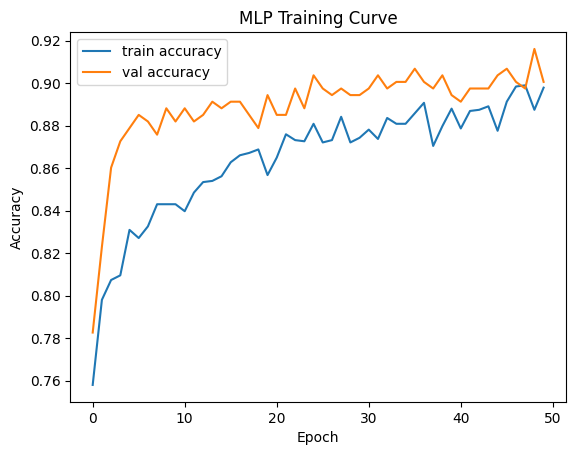

In [33]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

y_pred_nn = model.predict(X_test_scaled).argmax(axis=1) + 1  # back to 1-12 labels

print("=== Neural Network (MLP) ===")
print(classification_report(y_test, y_pred_nn, zero_division=0))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP Training Curve')
plt.show()

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_nn,
    validation_split=0.15,
    epochs=100,          # raised — early stopping will cut it short anyway
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8897 - loss: 0.3070 - val_accuracy: 0.9006 - val_loss: 0.3135
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8957 - loss: 0.2852 - val_accuracy: 0.8944 - val_loss: 0.2993
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8941 - loss: 0.2796 - val_accuracy: 0.9037 - val_loss: 0.3065
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8880 - loss: 0.2857 - val_accuracy: 0.9099 - val_loss: 0.3023
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9012 - loss: 0.2776 - val_accuracy: 0.8944 - val_loss: 0.3118
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8968 - loss: 0.3017 - val_accuracy: 0.9006 - val_loss: 0.3193
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8957 - loss: 0.2802 - val_accuracy: 0.8944 - val_loss: 0.3186
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8902 - loss: 0.2969 - val_accuracy: 0.8944 - v

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
=== Neural Network (MLP) ===
              precision    recall  f1-score   support

           1       0.78      0.89      0.83       152
           2       0.84      0.76      0.80       119
           3       0.79      0.91      0.85       135
           4       0.90      0.93      0.91       112
           5       0.88      0.87      0.87       157
           6       0.74      0.65      0.69       113
           7       0.91      0.98      0.95        97
           8       0.80      0.69      0.74       113
           9       0.75      0.57      0.65       100
          10       0.92      0.90      0.91       117
          11       0.64      0.77      0.70        96
          12       0.90      0.88      0.89       139

    accuracy                           0.82      1450
   macro avg       0.82      0.82      0.82      1450
weighted avg       0.82      0.82      0.82      1450



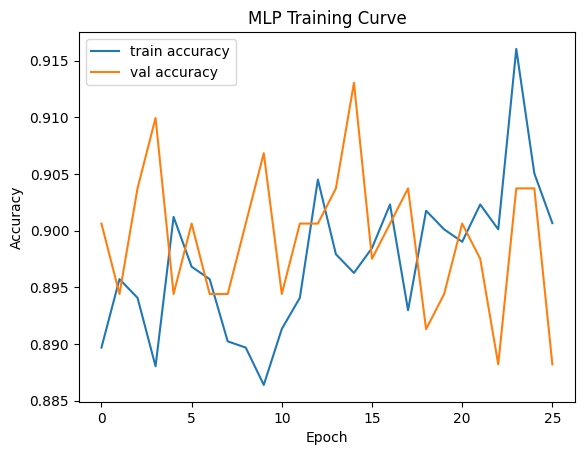

In [35]:
y_pred_nn = model.predict(X_test_scaled).argmax(axis=1) + 1  # back to 1-12 labels

print("=== Neural Network (MLP) ===")
print(classification_report(y_test, y_pred_nn, zero_division=0))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP Training Curve')
plt.show()

In [36]:
model_es = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(12, activation='softmax')
])

model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_es.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,740 (22.42 KB)

 Trainable params: 5,740 (22.42 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history_es = model_es.fit(
    X_train_scaled, y_train_nn,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2492 - loss: 2.2558 - val_accuracy: 0.4503 - val_loss: 1.9515
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4775 - loss: 1.7217 - val_accuracy: 0.5373 - val_loss: 1.5058
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5719 - loss: 1.3352 - val_accuracy: 0.7143 - val_loss: 1.1439
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6334 - loss: 1.0788 - val_accuracy: 0.7453 - val_loss: 0.9662
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6751 - loss: 0.9460 - val_accuracy: 0.7578 - val_loss: 0.8758
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7031 - loss: 0.8603 - val_accuracy: 0.7888 - val_loss: 0.7991
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7316 - loss: 0.7934 - val_accuracy: 0.7888 - val_loss: 0.7480
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7201 - loss: 0.7686 - val_accuracy: 0.8012 - v

In [38]:
from sklearn.metrics import classification_report

y_pred_es = model_es.predict(X_test_scaled).argmax(axis=1) + 1

print("=== Neural Network (MLP + EarlyStopping, fresh run) ===")
print(classification_report(y_test, y_pred_es, zero_division=0))

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Neural Network (MLP + EarlyStopping, fresh run) ===
              precision    recall  f1-score   support

           1       0.80      0.85      0.82       152
           2       0.87      0.79      0.83       119
           3       0.78      0.90      0.83       135
           4       0.89      0.90      0.89       112
           5       0.93      0.87      0.90       157
           6       0.76      0.61      0.68       113
           7       0.93      0.97      0.95        97
           8       0.84      0.71      0.77       113
           9       0.84      0.49      0.62       100
          10       0.86      0.89      0.87       117
          11       0.62      0.88      0.73        96
          12       0.80      0.93      0.86       139

    accuracy                           0.82      1450
   macro avg       0.83      0.81      0.81      1450
weighted avg       0.83      0.82      0.82      1450



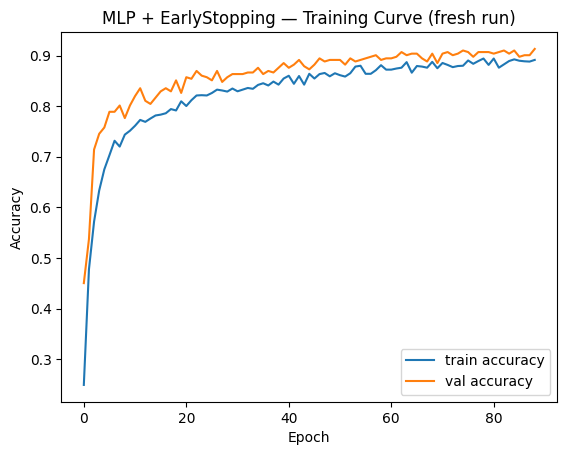

In [39]:
plt.plot(history_es.history['accuracy'], label='train accuracy')
plt.plot(history_es.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP + EarlyStopping — Training Curve (fresh run)')
plt.show()